In [21]:
import sys

if sys.version_info < (3, 10):
    raise RuntimeError("Python 3.10 or higher is required")

In [22]:
from packaging.version import Version
import sklearn

if Version(sklearn.__version__) < Version('1.6.1'):
    raise RuntimeError("scikit-learn >= 1.6.1 is required")

#### The following code fetches the MNIST dataset from OpenML.org

In [23]:
from sklearn.datasets import fetch_openml

mist = fetch_openml('mnist_784', as_frame=False)

In [24]:
mist

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',


In [25]:
X, y = mist.data, mist.target

In [26]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [27]:
X.shape

(70000, 784)

In [28]:
y.shape

(70000,)

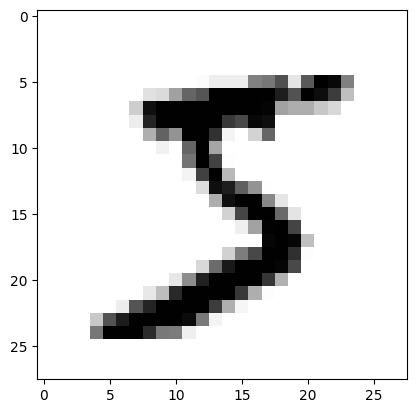

In [29]:
import matplotlib.pyplot as plt

def plot_digit(data):
    plt.imshow(data.reshape(28, 28), cmap='binary')

some_digit = X[0]
plot_digit(some_digit)

In [30]:
y[0]

'5'

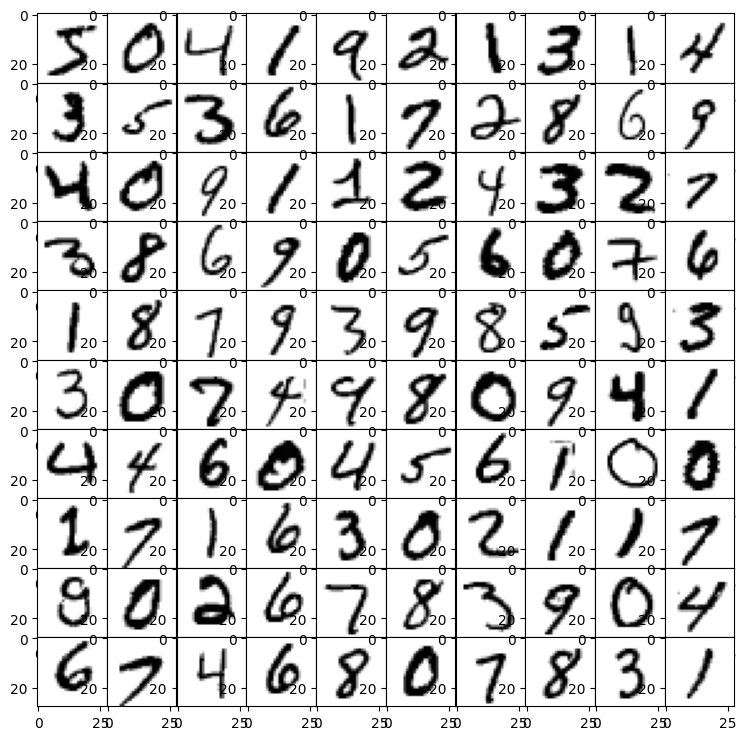

In [ ]:
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)

plt.show()

###### MNIST is a famous, standardized dataset that the machine learning community has been using for decades. The creators already decided: First 60,000 samples  → Training set Last 10,000 samples   → Test set This is the official, universally accepted split for MNIST. Every researcher in every paper uses this same split, so results are directly comparable across the world.

In [32]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [33]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [35]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=123)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [36]:
sgd_clf.predict([some_digit])

array([ True])

In [38]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95505, 0.9018 , 0.9697 ])